In [ ]:
# Install sentence-transformers
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

# 10 sentences across 3 topics (at least 3 per topic)
sentences = [
    # Cricket
    "The batsman hit a magnificent six over the boundary.",
    "The bowler delivered a perfect yorker to dismiss the opener.",
    "India won the match by chasing down the target in 45 overs.",
    "The fielder took a stunning catch at the boundary rope.",

    # Cooking
    "Saute the onions in olive oil until they turn golden brown.",
    "Add a pinch of salt and pepper to season the soup.",
    "The dough must be kneaded for ten minutes before baking.",

    # Cybersecurity
    "The hacker exploited a SQL injection vulnerability in the web application.",
    "A strong password should contain uppercase letters, numbers, and symbols.",
    "Firewalls are used to monitor and filter incoming network traffic.",
]

# Load the model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f"Number of sentences: {len(sentences)}")
print(f"Embedding shape: {embeddings.shape}")
print("\nSentences loaded successfully!")
for i, s in enumerate(sentences):
    print(f"  [{i+1}] {s}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of sentences: 10
Embedding shape: (10, 384)

Sentences loaded successfully!
  [1] The batsman hit a magnificent six over the boundary.
  [2] The bowler delivered a perfect yorker to dismiss the opener.
  [3] India won the match by chasing down the target in 45 overs.
  [4] The fielder took a stunning catch at the boundary rope.
  [5] Saute the onions in olive oil until they turn golden brown.
  [6] Add a pinch of salt and pepper to season the soup.
  [7] The dough must be kneaded for ten minutes before baking.
  [8] The hacker exploited a SQL injection vulnerability in the web application.
  [9] A strong password should contain uppercase letters, numbers, and symbols.
  [10] Firewalls are used to monitor and filter incoming network traffic.


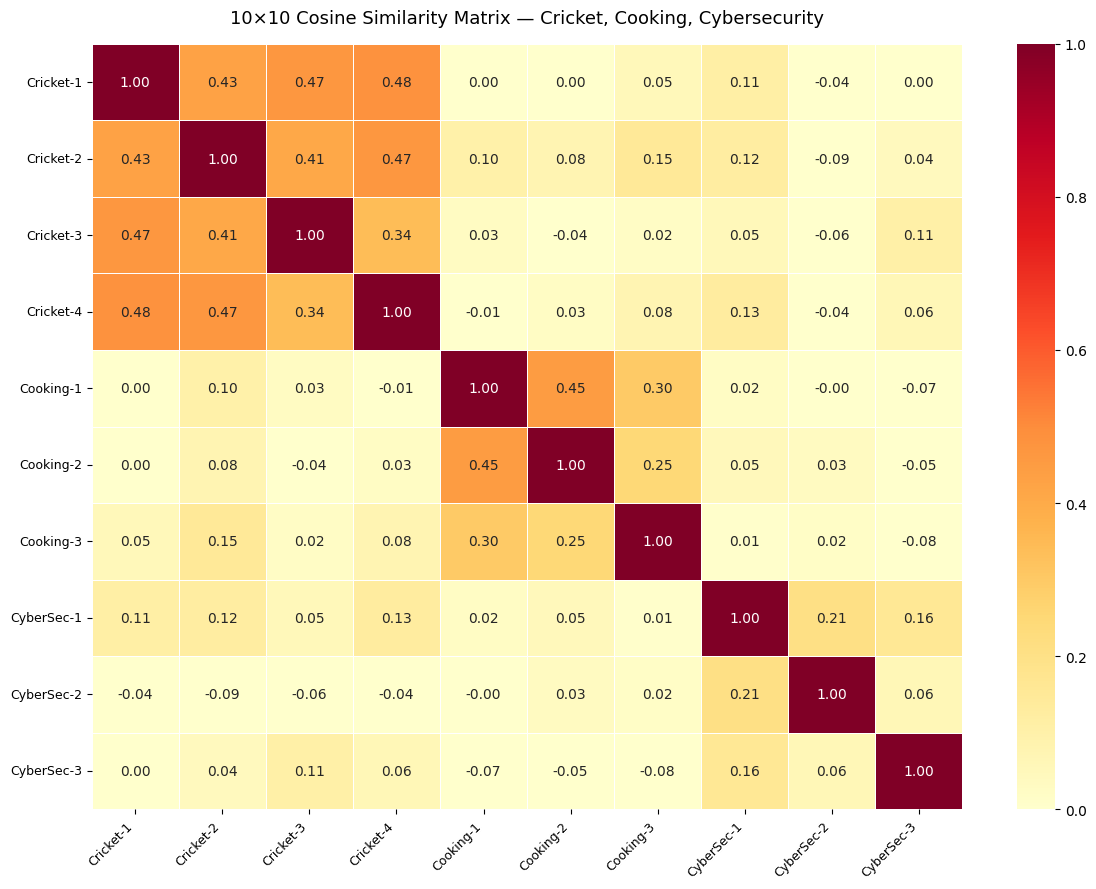

Heatmap saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Compute 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Short labels for the heatmap axes
labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "CyberSec-1", "CyberSec-2", "CyberSec-3"
]

# Plot the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0, vmax=1
)
plt.title("10×10 Cosine Similarity Matrix — Cricket, Cooking, Cybersecurity",
          fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved!")

In [ ]:
# Query sentence from the assignment
query = "The bowler took three wickets in one over"

# Generate embedding for the query
query_embedding = model.encode([query])

# Compute cosine similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Sort by similarity score (highest first)
ranked = sorted(enumerate(query_similarities), key=lambda x: x[1], reverse=True)

print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:\n")
for rank, (idx, score) in enumerate(ranked[:2], 1):
    print(f"  Rank {rank}: [{score:.4f}] {sentences[idx]}")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:

  Rank 1: [0.5692] India won the match by chasing down the target in 45 overs.
  Rank 2: [0.5549] The batsman hit a magnificent six over the boundary.
